# Reweighting Motivation and Goal
In this notebook, I explore the impact of reweighting as a bias mitigation strategy for gender-based disparities in income prediction. The key motivation behind applying reweighting was to address two concerns:

Fairness: The original model was noticeably better at predicting high-income individuals among men compared to women — a sign of social bias embedded in the data.

Representation: Women earning more than $50K formed a much smaller class in the training set, which may have caused the model to underperform on them.

To mitigate this, I applied a reweighting strategy. I computed the joint probabilities of (gender, income) combinations in the training data and then assigned inverse-probability weights: giving higher weights to underrepresented combinations like women earning more than $50K. These weights were then normalized to sum to 1 and passed into model training using the sample_weight parameter.

The sensitive attribute considered was gender, and the target was income class.

# Evaluation Plan
In this notebook, I aim to evaluate whether reweighting:

Improves overall F1-score

Increases recall for women earning more than $50K

Reduces disparities in fairness metrics such as:

Statistical parity

Equal opportunity

The focus on recall (especially for the underrepresented class) is important, as it reflects how many of the true high-income women the model successfully identifies.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [10]:
import os
import json
import pandas as pd

comparison_data = {
    'Logistic Regression': {},
    'Random Forest': {},
    'Gradient Boosting': {}
}

# Load Reweighed Results
reweighed_results_path = "../outputs/reweighed_results/"
reweighed_files = [f for f in os.listdir(reweighed_results_path) if f.endswith('.json') and f != "sample_weights.json"]

for file_name in reweighed_files:
    model_key = file_name.replace(".json", "")  
    model_name = model_key.replace('_reweighted', '')  

    if model_name in comparison_data:
        full_path = os.path.join(reweighed_results_path, file_name)
        with open(full_path, 'r') as f:
            data = json.load(f)
            comparison_data[model_name]['reweighed'] = data.get(model_key, data)

# Load Unweighed (Original) Results
results_path = "../outputs/results/"
baseline_files = [f for f in os.listdir(results_path) if f.endswith('.json') and f != "fairness_metrics.json"]

for file_name in baseline_files:
    model_name = file_name.replace(".json", "")  

    if model_name in comparison_data:
        full_path = os.path.join(results_path, file_name)
        with open(full_path, 'r') as f:
            data = json.load(f)
            comparison_data[model_name]['unweighed'] = data.get(model_name, data)

pd.set_option('display.max_colwidth', None)

# Load Dataframes
logreg_df = pd.DataFrame({
    'reweighed': comparison_data['Logistic Regression'].get('reweighed', {}),
    'unweighed': comparison_data['Logistic Regression'].get('unweighed', {})
})

ranforest_df = pd.DataFrame({
    'reweighed': comparison_data['Random Forest'].get('reweighed', {}),
    'unweighed': comparison_data['Random Forest'].get('unweighed', {})
})

gb_df = pd.DataFrame({
    'reweighed': comparison_data['Gradient Boosting'].get('reweighed', {}),
    'unweighed': comparison_data['Gradient Boosting'].get('unweighed', {})
})

print("\nLogistic Regression Comparison")
print(logreg_df)

print("\nRandom Forest Comparison")
print(ranforest_df)

print("\nGradient Boosting Comparison")
print(gb_df)



Logistic Regression Comparison
                                                                                                                       reweighed  \
0               {'precision': 0.8217610550814585, 'recall': 0.93511366144339, 'f1-score': 0.8747806338391659, 'support': 4531.0}   
1             {'precision': 0.6647662485746865, 'recall': 0.3881491344873502, 'f1-score': 0.4901218999579655, 'support': 1502.0}   
accuracy                                                                                                                0.798939   
macro avg     {'precision': 0.7432636518280724, 'recall': 0.6616313979653701, 'f1-score': 0.6824512668985657, 'support': 6033.0}   
weighted avg  {'precision': 0.7826749951820434, 'recall': 0.7989391679098292, 'f1-score': 0.7790144448304533, 'support': 6033.0}   

                                                                                                                       unweighed  
0             {'precision': 0.90062790062790

For both Logistic Regression and Gradient Boosting, reweighing led to a noticeable increase in overall accuracy. This was primarily due to improved recall on the majority class (low earners), which dominates the dataset. However, this came at the cost of reduced precision and F1-score for the minority class (high earners), meaning the model became less reliable for predicting high earners accurately. The Random Forest model’s performance changed only slightly after reweighing, showing minimal impact from the intervention.

Reweighing improved overall accuracy and class balance, but it reduced model effectiveness at correctly identifying high earners, especially women, who are already a double minority (female + high income).

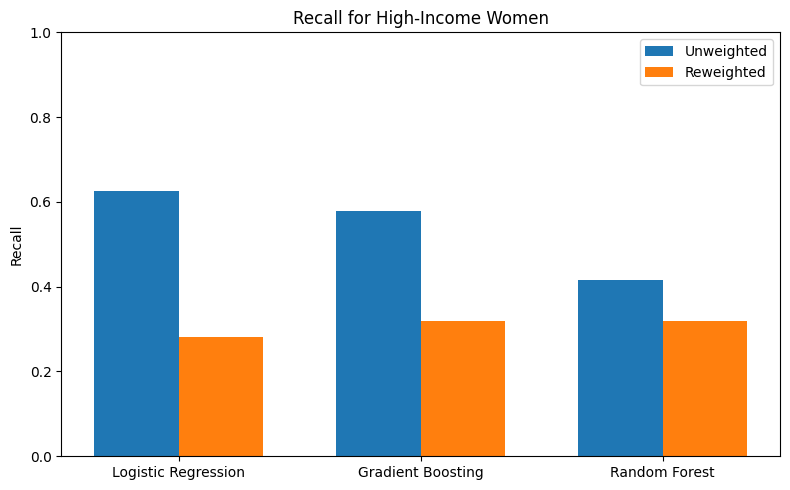

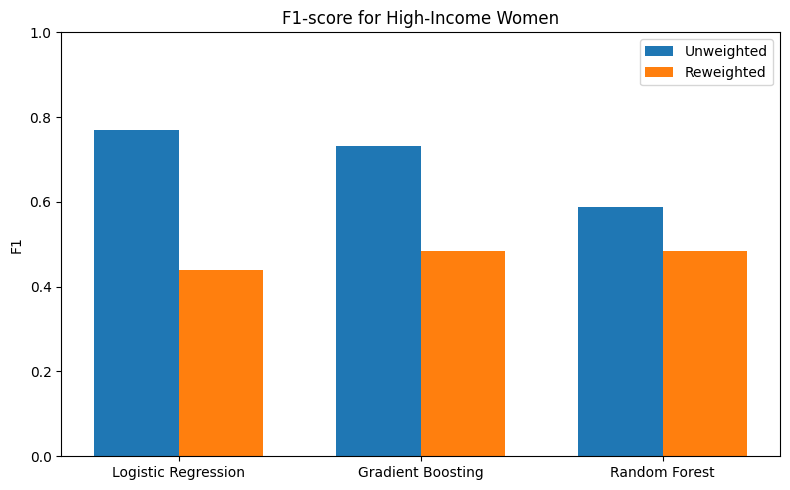

In [ ]:
# Finding the impact of reweighing on the high-income women minority
import sys
import os
sys.path.append(os.path.abspath(".."))
from utils import eval_helper as ev
from utils import plot_helper as plot

# Model filenames
model_pairs = [
    ("Logistic Regression_preds.npz", "Logistic Regression_reweighted_preds.npz"),
    ("Gradient Boosting_preds.npz", "Gradient Boosting_reweighted_preds.npz"),
    ("Random Forest_preds.npz", "Random Forest_reweighted_preds.npz")
]

results = []
for unweighted, reweighted in model_pairs:
    base = unweighted.split("_preds")[0]
    results.append(ev.evaluate_high_income_women(f"../outputs/preds/{unweighted}", base + " (Unweighted)"))
    results.append(ev.evaluate_high_income_women(f"../outputs/preds/{reweighted}", base + " (Reweighted)"))

plot.plot_metric_comparison(results, "recall", "Recall for High-Income Women")
plot.plot_metric_comparison(results, "f1", "F1-score for High-Income Women")

Reweighting reduced F1 and recall scores for high-income women across all models, indicating that fairness improvements may have come at the cost of predictive performance on this subgroup.